# Рекомендательная система на MovieLens 100K

Делаем рекомендательную систему фильмов. Наша задача предсказывать оценки и выдавать топ-10 рекомендаций для каждого пользователя. Хорошей рекомендацией будем считать фильм, которому пользователь поставил 4 или 5.

In [56]:
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
from surprise import Dataset, Reader, KNNBaseline, SVD

warnings.filterwarnings('ignore')

url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
zip_path = 'ml-100k.zip'

if not os.path.exists('ml-100k'):
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    os.remove(zip_path)

## Исследование данных



In [51]:
cols = ['user_id', 'item_id', 'rating', 'timestamp']
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=cols)

n_users = ratings['user_id'].nunique()
n_items = ratings['item_id'].nunique()

total_possible = n_users * n_items
sparsity = 1 - (len(ratings) / total_possible)

print('Пользователей:', n_users)
print('Фильмов:', n_items)
print('Разреженность матрицы:', round(sparsity, 4))

Пользователей: 943
Фильмов: 1682
Разреженность матрицы: 0.937


### Распределение оценок


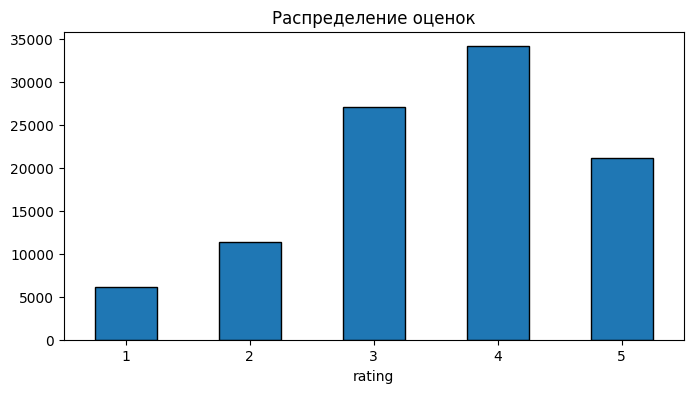

In [50]:
ratings['rating'].value_counts().sort_index().plot(
    kind='bar',
    title='Распределение оценок',
    edgecolor='black',
    figsize=(8, 4),
    rot=0
)
plt.show()

По графику распределения оценок видно, что люди чаще всего ставят 4, 3 или 5, а вот 1 и 2 встречаются очень редко. Это логично, потому что зрители обычно досматривают и оценивают только то кино, которое им понравилось.

### Активность пользователей


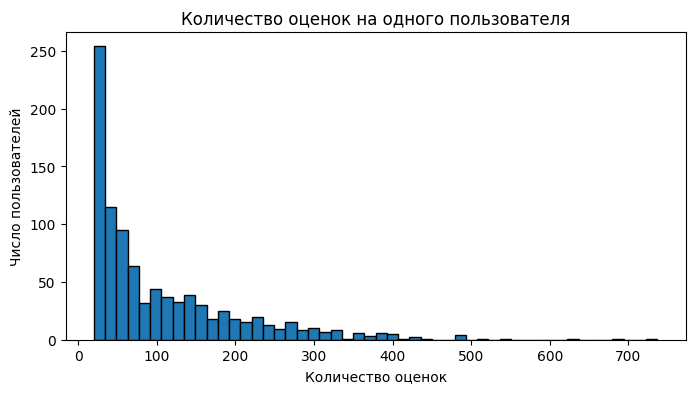

Медианное число оценок у пользователя: 65
Минимальное число оценок: 20


In [52]:
user_activity = ratings.groupby('user_id').size()

plt.figure(figsize=(8, 4))
plt.hist(user_activity, bins=50, edgecolor='black')
plt.title('Количество оценок на одного пользователя')
plt.xlabel('Количество оценок')
plt.ylabel('Число пользователей')
plt.show()

print('Медианное число оценок у пользователя:', int(user_activity.median()))
print('Минимальное число оценок:', user_activity.min())

Половина всех людей поставила максимум 65 оценок, а  минимальное значение 20. Из этого понятно, почему делать рекомендации сложно, ведь большинство пользователей дает слишком мало данных о своих предпочтениях.

### Анализ фильмов


In [49]:
item_cols = ['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + [
    'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

items = pd.read_csv('ml-100k/u.item', sep='|', names=item_cols, encoding='latin-1')

movie_stats = ratings.groupby('item_id').agg(
    ratings_count=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()

movie_stats = movie_stats.merge(items[['item_id', 'title']], on='item_id')

display(movie_stats.sort_values('ratings_count', ascending=False).head(10)[['title', 'ratings_count', 'mean_rating']])

,title,ratings_count,mean_rating
49,Star Wars (1977),583,4.358491
257,Contact (1997),509,3.803536
99,Fargo (1996),508,4.155512
180,Return of the Jedi (1983),507,4.007890
293,Liar Liar (1997),485,3.156701
285,"English Patient, The (1996)",481,3.656965
287,Scream (1996),478,3.441423
0,Toy Story (1995),452,3.878319
299,Air Force One (1997),431,3.631090
120,Independence Day (ID4) (1996),429,3.438228


В топе самых популярных фильмов находятся хиты по типу Звездных войн или первой части Истории игрушек. У них сотни отзывов и стабильно высокий средний балл от 3.15 до 4.35. Именно такие фильмы и забирают на себя почти все внимание зрителей.

### Связь количества оценок и рейтинга


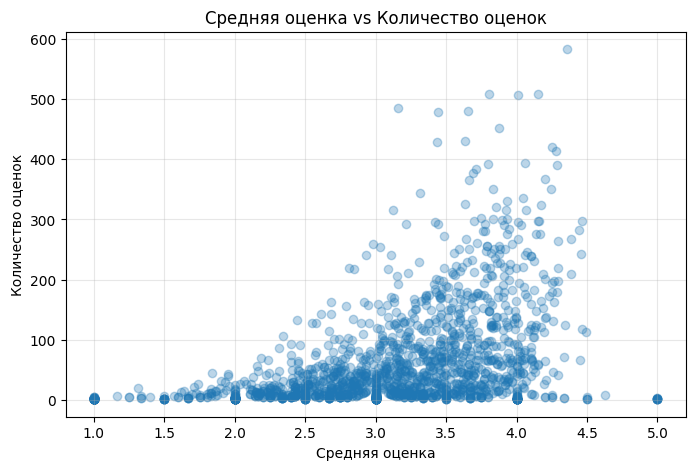

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(movie_stats['mean_rating'], movie_stats['ratings_count'], alpha=0.3)
plt.title('Средняя оценка vs Количество оценок')
plt.xlabel('Средняя оценка')
plt.ylabel('Количество оценок')
plt.grid(True, alpha=0.3)
plt.show()

У непопулярных фильмов оценки разбросаны как попало, там есть ровно 1.0 и 5.0. Но чем больше людей посмотрели фильм, тем сильнее его рейтинг выравнивается и держится где-то между 3.5 и 4.5 баллами.

## Разбиение выборки
Берем последние 20% оценок каждого пользователя в тест, чтобы не заглядывать в будущее. Остальное идет в обучающую выборку.

In [21]:
ratings = ratings.sort_values(['user_id', 'timestamp'])

train_data = []
test_data = []

for uid, group in ratings.groupby('user_id'):
    n_test = int(len(group) * 0.2)
    if n_test == 0 and len(group) > 1:
        n_test = 1

    train_data.append(group.iloc[:-n_test])
    test_data.append(group.iloc[-n_test:])

train = pd.concat(train_data)
test = pd.concat(test_data)

print('Размер трейна:', len(train))
print('Размер теста:', len(test))

Размер трейна: 80367
Размер теста: 19633


## Метрики ранжирования


In [54]:
THRESHOLD = 4
K = 10

def get_metrics(recs, true_items):
    if not true_items:
        return None

    recs_k = recs[:K]
    hits = len(set(recs_k) & set(true_items))

    precision = hits / K
    recall = hits / len(true_items)

    ap = 0
    hits_count = 0
    for i, item in enumerate(recs_k):
        if item in true_items:
            hits_count += 1
            ap += hits_count / (i + 1)
    map_k = ap / min(len(true_items), K)

    dcg = sum([1 / np.log2(i + 2) for i, item in enumerate(recs_k) if item in true_items])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(true_items), K))])
    ndcg = dcg / idcg if idcg > 0 else 0

    return precision, recall, map_k, ndcg

test_relevant = defaultdict(set)
for index, row in test[test['rating'] >= THRESHOLD].iterrows():
    test_relevant[row['user_id']].add(row['item_id'])

user_history = defaultdict(set)
for index, row in train.iterrows():
    user_history[row['user_id']].add(row['item_id'])

## Popularity Baseline
Отбрасываем фильмы, у которых оценок меньше 15, чтобы в рекомендациях не было случайного непопулярного мусора. Потом рекомендуем то, что чаще всего оценивают высоко.

In [55]:
counts = train['item_id'].value_counts()
good_items = set(counts[counts >= 15].index)

pop = train[train['rating'] >= THRESHOLD].groupby('item_id').size()
pop = pop.sort_values(ascending=False)
pop_items = [x for x in pop.index if x in good_items]

baseline_metrics = []

for uid, true_items in test_relevant.items():
    seen = user_history.get(uid, set())
    recs = [x for x in pop_items if x not in seen][:K]

    m = get_metrics(recs, true_items)
    if m:
        baseline_metrics.append(m)

pop_res = np.mean(baseline_metrics, axis=0)

## Коллаборативная фильтрация и SVD

In [61]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(train[['user_id', 'item_id', 'rating']], reader)
trainset = data.build_full_trainset()

all_items = set(train['item_id'].unique())
preds_data = []

for uid in test_relevant.keys():
    seen = user_history.get(uid, set())
    candidates = (all_items - seen) & good_items
    for item in candidates:
        preds_data.append((uid, item, 0))

def evaluate_model(model):
    predictions = model.test(preds_data)

    recs = defaultdict(list)
    for uid, iid, true_r, est, details in predictions:
        recs[uid].append((iid, est))

    metrics_list = []
    for uid, user_preds in recs.items():
        user_preds.sort(key=lambda x: x[1], reverse=True)
        top = [x[0] for x in user_preds[:K]]

        m = get_metrics(top, test_relevant[uid])
        if m:
            metrics_list.append(m)

    return np.mean(metrics_list, axis=0)

sim_user = {'name': 'cosine', 'user_based': True, 'min_support': 5}
user_cf = KNNBaseline(sim_options=sim_user, verbose=False)
user_cf.fit(trainset)
ub_res = evaluate_model(user_cf)

sim_item = {'name': 'cosine', 'user_based': False, 'min_support': 5}
item_cf = KNNBaseline(sim_options=sim_item, verbose=False)
item_cf.fit(trainset)
ib_res = evaluate_model(item_cf)

svd = SVD(n_factors=50, reg_all=0.08, random_state=44)
svd.fit(trainset)
svd_res = evaluate_model(svd)

## Эволюция вкусов и проблема длинного хвоста

Проверим гипотезу о том, что пользователи сначала смотрят популярные хиты, а со временем их вкус становится более специфичным. Если это так, то в тестовой выборке фильмы должны быть в среднем менее популярными, чем в обучающей.

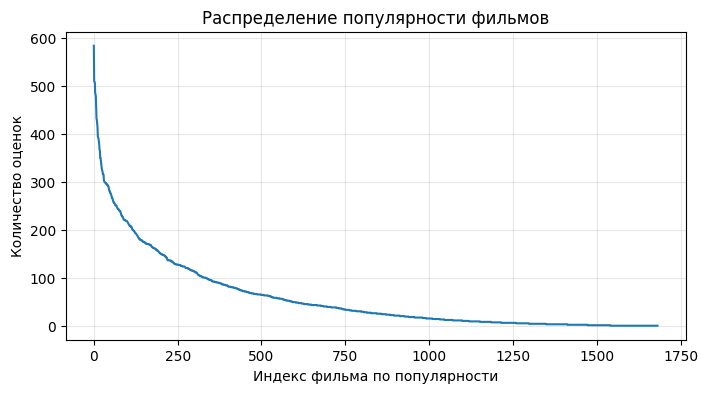

Средняя популярность фильма в трейне: 177
Средняя популярность фильма в тесте: 131


In [62]:
item_counts = ratings['item_id'].value_counts()

plt.figure(figsize=(8, 4))
plt.plot(item_counts.values)
plt.title('Распределение популярности фильмов')
plt.xlabel('Индекс фильма по популярности')
plt.ylabel('Количество оценок')
plt.grid(True, alpha=0.3)
plt.show()

pop_dict = item_counts.to_dict()

train_pop = train['item_id'].map(pop_dict).mean()
test_pop = test['item_id'].map(pop_dict).mean()

print('Средняя популярность фильма в трейне:', int(train_pop))
print('Средняя популярность фильма в тесте:', int(test_pop))

На графике отлично виден этот длинный хвост. Слева находится небольшая кучка хитов, у которых сотни оценок. А вправо тянется хвост из тысяч фильмов, которые люди смотрели буквально пару раз. И как раз в этом хвосте рекомендательным моделям сложнее всего работать из-за нехватки данных.

# Итоги и выводы

In [63]:
res_df = pd.DataFrame({
    'Popularity': pop_res,
    'User-based CF': ub_res,
    'Item-based CF': ib_res,
    'SVD': svd_res
}, index=['Precision@10', 'Recall@10', 'MAP@10', 'NDCG@10'])

print(res_df.T.round(4))

               Precision@10  Recall@10  MAP@10  NDCG@10
Popularity           0.0777     0.0765  0.0494   0.1006
User-based CF        0.0418     0.0399  0.0217   0.0507
Item-based CF        0.0459     0.0435  0.0214   0.0522
SVD                  0.0408     0.0407  0.0192   0.0467


**Выводы по результатам**

1. Проблема длинного хвоста.

По данным хорошо видно, что со временем вкусы зрителей меняются. Сначала люди смотрят популярные хиты, а потом переходят на редкое нишевое кино. В тестовой выборке фильмы в среднем оказались менее популярными.

2. Почему популярность работает хорошо.

Модели пытаются угадать редкие интересы, но им не хватает данных, поэтому они часто ошибаются.
Попасть в точку с редким фильмом очень тяжело. А обычный бейзлайн работает грубо, но надежно,
просто предлагая хиты, которые и так нравятся большинству.

3. Проблема самих метрик.

Алгоритмы из библиотеки surprise оптимизируют ошибку предсказания оценки, а не качество
ранжирования. Модель может понять, что редкий артхаус понравится на 5 баллов, и поставить
его на самый верх. Но в реальности человек вечером скорее выберет посмотреть знакомый блокбастер
на 4 балла.

На практике же эти проблемы решают через каскад моделей. Процесс разбивают на несколько этапов, где на каждом шаге количество подходящих кандидатов постепенно сужается.

Сначала простые и быстрые алгоритмы отбирают тысячи возможных фильмов из всего огромного каталога. Затем промежуточные фильтры сокращают этот объем до нескольких сотен. И только в самом конце тяжелая модель финально ранжирует этот короткий список. Она сводит вместе личные интересы пользователя и общую популярность контента, чтобы итоговые К рекомендаций выглядели максимально логично.